In [75]:
import pandas as pd
df = pd.read_csv("Nassau Candy Distributor.csv")

In [76]:
print("Before Cleaning:")
print(df.shape)
print(df.isnull().sum())

Before Cleaning:
(10194, 18)
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64


In [77]:
df = df[(df['Sales'] > 0) & (df['Cost'] > 0)]

In [78]:
df = df[df['Gross Profit'] != 0]


In [79]:
df['Units'] = df['Units'].fillna(df['Units'].median())

In [80]:
df['Product Name'] = df['Product Name'].str.strip()
df['Division'] = df['Division'].str.strip()

In [81]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [82]:
print("\nAfter Cleaning:")
print(df.shape)
print(df.isnull().sum())


After Cleaning:
(10194, 18)
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64


In [83]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [84]:
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64


In [85]:
print("\nNegative Sales:", (df['Sales'] < 0).sum())
print("Negative Cost:", (df['Cost'] < 0).sum())


Negative Sales: 0
Negative Cost: 0


In [86]:
print("\nZero Sales:", (df['Sales'] == 0).sum())
print("Zero Cost:", (df['Cost'] == 0).sum())
print("Zero Profit:", (df['Gross Profit'] == 0).sum())


Zero Sales: 0
Zero Cost: 0
Zero Profit: 0


In [87]:
print("\nDuplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


In [88]:
print("\nOrder Date Range:", df['Order Date'].min(), "to", df['Order Date'].max())
print("Ship Date Range:", df['Ship Date'].min(), "to", df['Ship Date'].max())


Order Date Range: 2024-01-02 00:00:00 to 2025-12-31 00:00:00
Ship Date Range: 2026-06-30 00:00:00 to 2030-06-28 00:00:00


In [89]:
df['Gross Margin (%)'] = (df['Gross Profit'] / df['Sales']) * 100

In [90]:
df['Profit per Unit'] = df['Gross Profit'] / df['Units']

In [91]:
total_sales = df['Sales'].sum()
total_profit = df['Gross Profit'].sum()

In [92]:
df['Revenue Contribution (%)'] = (df['Sales'] / total_sales) * 100

In [93]:
df['Profit Contribution (%)'] = (df['Gross Profit'] / total_profit) * 100

In [94]:
df[['Product Name', 'Sales', 'Gross Profit', 'Gross Margin (%)', 
    'Profit per Unit', 'Revenue Contribution (%)', 
    'Profit Contribution (%)']].head()

,Product Name,Sales,Gross Profit,Gross Margin (%),Profit per Unit,Revenue Contribution (%),Profit Contribution (%)
0,Wonka Bar - Milk Chocolate,6.50,4.22,64.923077,2.11,0.004584,0.004516
1,Wonka Bar - Triple Dazzle Caramel,7.50,4.90,65.333333,2.45,0.005290,0.005244
2,Wonka Bar - Nutty Crunch Surprise,10.47,7.47,71.346705,2.49,0.007384,0.007994
3,Wonka Bar -Scrumdiddlyumptious,10.80,7.50,69.444444,2.50,0.007617,0.008026
4,Wonka Bar - Triple Dazzle Caramel,11.25,7.35,65.333333,2.45,0.007935,0.007866


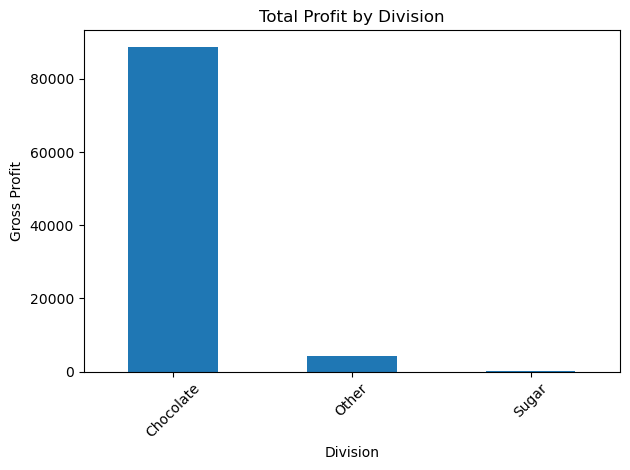

In [95]:
import matplotlib.pyplot as plt

division_profit = df.groupby('Division')['Gross Profit'].sum().sort_values(ascending=False)

plt.figure()
division_profit.plot(kind='bar')

plt.title("Total Profit by Division")
plt.xlabel("Division")
plt.ylabel("Gross Profit")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

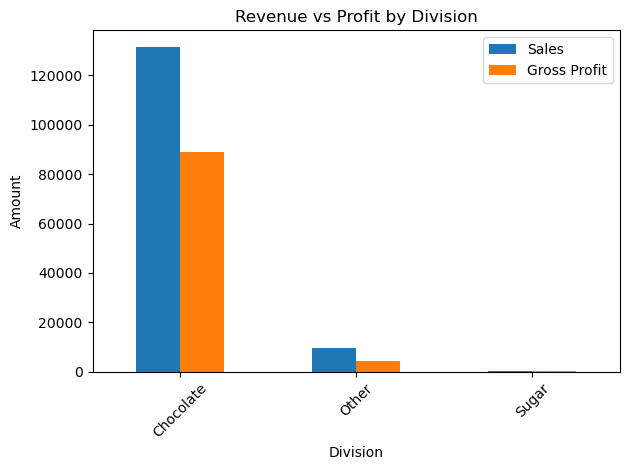

In [96]:
division_data = df.groupby('Division').agg({
    'Sales': 'sum',
    'Gross Profit': 'sum'
}).sort_values(by='Sales', ascending=False)

division_data.plot(kind='bar')

plt.title("Revenue vs Profit by Division")
plt.xlabel("Division")
plt.ylabel("Amount")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

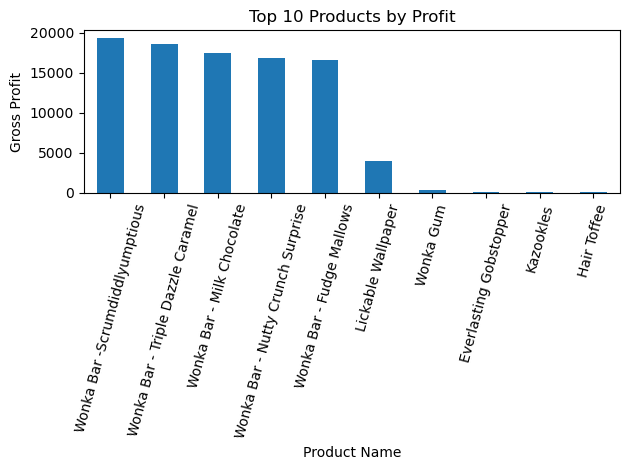

In [97]:
top_profit_products = df.groupby('Product Name')['Gross Profit'].sum().sort_values(ascending=False).head(10)

plt.figure()
top_profit_products.plot(kind='bar')

plt.title("Top 10 Products by Profit")
plt.xlabel("Product Name")
plt.ylabel("Gross Profit")

plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

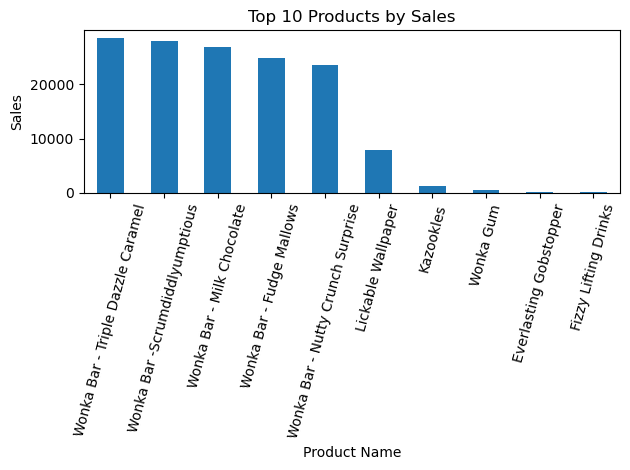

In [98]:
top_sales_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure()
top_sales_products.plot(kind='bar')

plt.title("Top 10 Products by Sales")
plt.xlabel("Product Name")
plt.ylabel("Sales")

plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

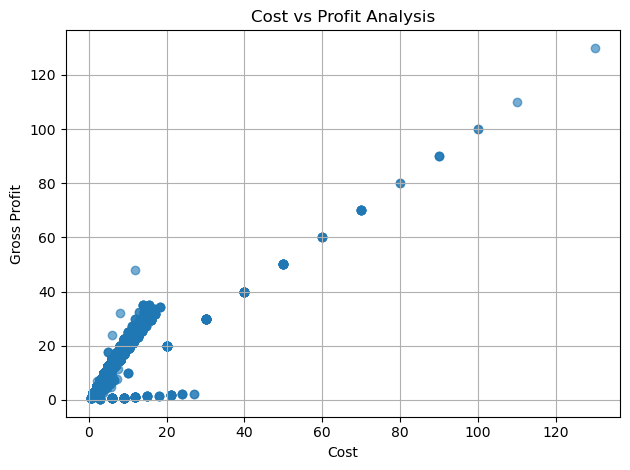

In [99]:
plt.figure()

plt.scatter(df['Cost'], df['Gross Profit'], alpha=0.6)

plt.title("Cost vs Profit Analysis")
plt.xlabel("Cost")
plt.ylabel("Gross Profit")

plt.grid(True)  # clean grid instead of dotted mess
plt.tight_layout()
plt.show()

In [100]:
pareto = df.groupby('Product Name')['Gross Profit'].sum().sort_values(ascending=False)

In [101]:
pareto_df = pareto.reset_index()
pareto_df['Cumulative %'] = pareto_df['Gross Profit'].cumsum() / pareto_df['Gross Profit'].sum() * 100

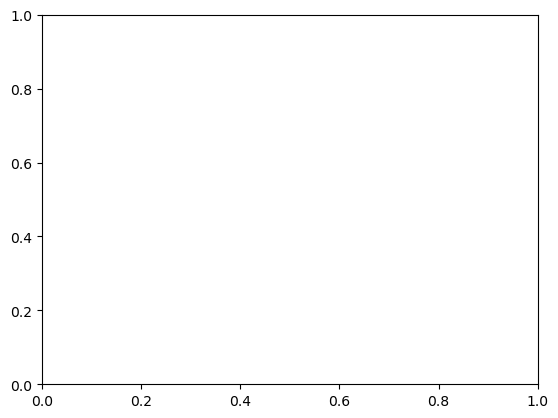

In [102]:
fig, ax1 = plt.subplots()

In [103]:
ax1.bar(pareto_df['Product Name'], pareto_df['Gross Profit'])
ax1.set_ylabel('Gross Profit')

Text(4.444444444444452, 0.5, 'Gross Profit')

In [104]:
ax2 = ax1.twinx()
ax2.plot(pareto_df['Product Name'], pareto_df['Cumulative %'])
ax2.set_ylabel('Cumulative %')

Text(0, 0.5, 'Cumulative %')

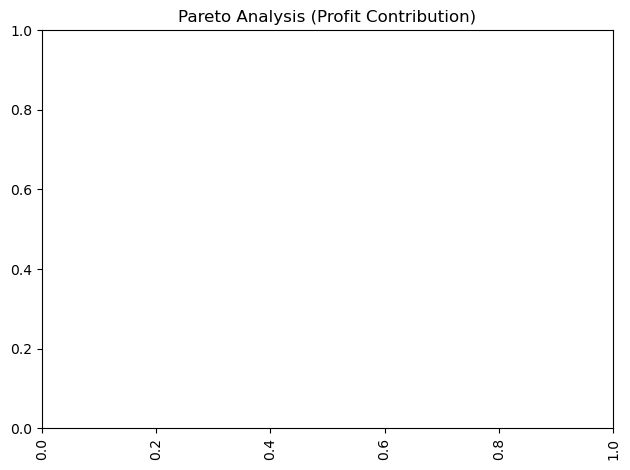

In [105]:
plt.title("Pareto Analysis (Profit Contribution)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()